HYPERNET
=== Run 1 =============
Matthews Corr:
  Mean: 0.5719
  Median: 0.5869
  Best: 0.6197 (EPOCH: 45)
Eval Loss:
  Mean: 0.6021
  Median: 0.6007
  Best: 0.3994 (EPOCH: 6)
Train Loss:
  Mean: 0.2107
  Median: 0.1719
  Best: 0.1049 (EPOCH: 77)
Eval ECE score:
  Mean: 0.1223
  Median: 0.1325
  Best: 0.0331 (EPOCH: 6)
Eval B matrix std:
  Mean: 0.1597
  Median: 0.1570
  Best: 0.2359 (EPOCH: 17)
=== Run 2 =============
Matthews Corr:
  Mean: 0.5759
  Median: 0.5931
  Best: 0.6316 (EPOCH: 62)
Eval Loss:
  Mean: 0.6049
  Median: 0.5991
  Best: 0.4022 (EPOCH: 15)
Train Loss:
  Mean: 0.2009
  Median: 0.1629
  Best: 0.0981 (EPOCH: 76)
Eval ECE score:
  Mean: 0.1201
  Median: 0.1272
  Best: 0.0570 (EPOCH: 6)
Eval B matrix std:
  Mean: 0.1551
  Median: 0.1522
  Best: 0.2330 (EPOCH: 32)

BASELINE
=== Run 1 =============
Matthews Corr:
  Mean: 0.5752
  Median: 0.5855
  Best: 0.6308 (EPOCH: 31)
Eval Loss:
  Mean: 0.7429
  Median: 0.7260
  Best: 0.3917 (EPOCH: 5)
Train Loss:
  Mean: 0.1719
  Medi

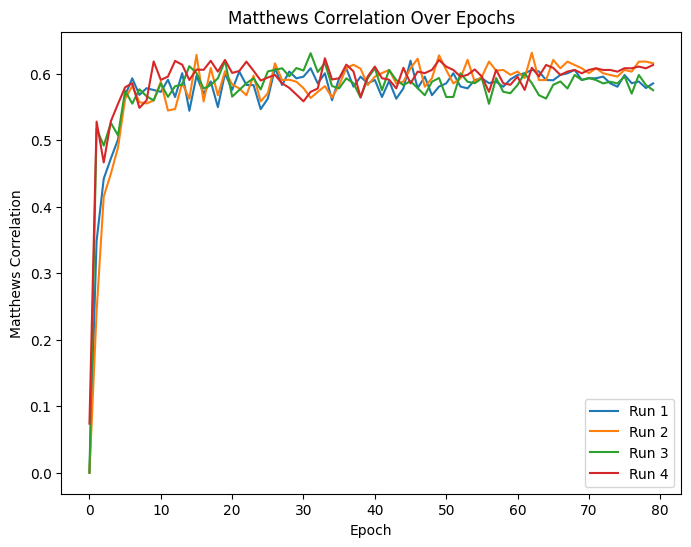

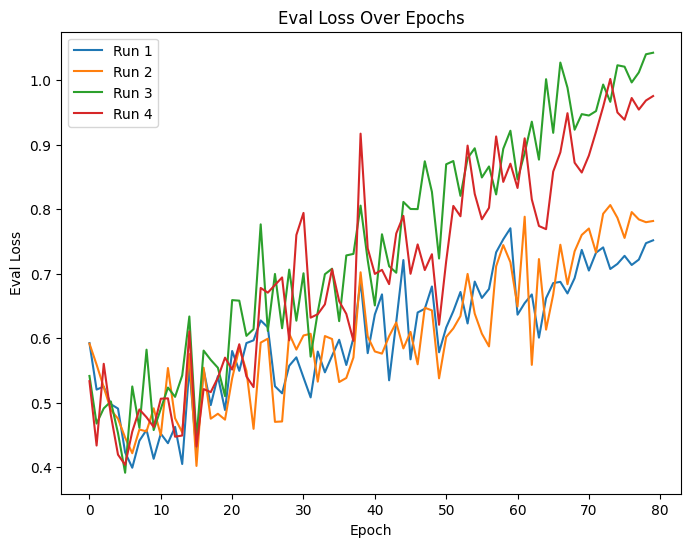

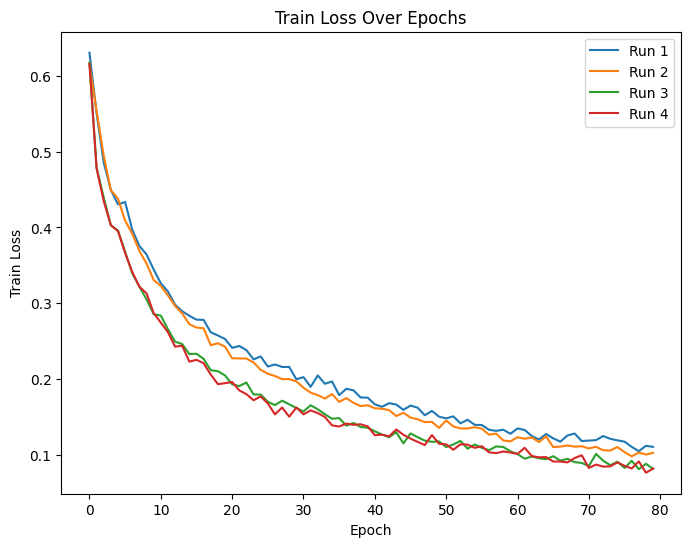

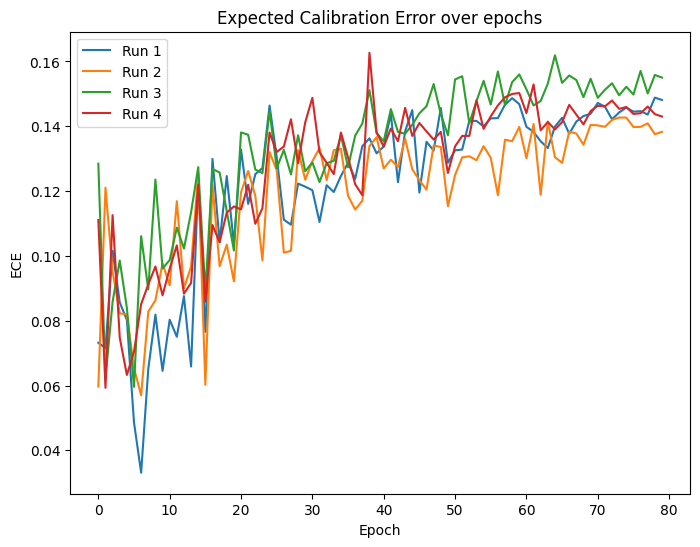

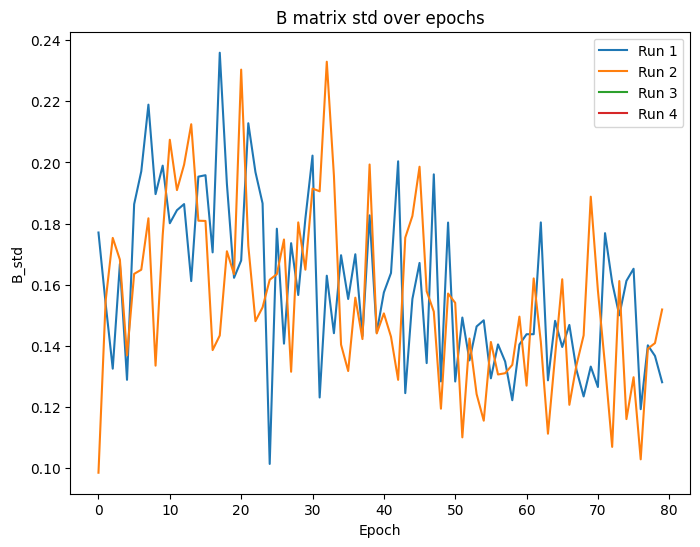

In [14]:
import json
import matplotlib.pyplot as plt

def get_results_from_slurm(file_path: str):
    with open(file_path, "r", encoding="utf-8") as f:
        txt = f.read()
        lines = txt.split("\n")
        
        results = []
        
        for line in lines:
            if len(line) > 0 and line[0] == "{":
                obj = json.loads(line.replace("'", '"'))
                
                if "eval_loss" in obj:
                    results[-1]["eval_loss"].append(obj["eval_loss"])
                    if "eval_matthews_correlation" in obj:
                        results[-1]["matthews"].append(obj["eval_matthews_correlation"])
                    if "eval_ece" in obj:
                        results[-1]["ece"].append(obj["eval_ece"])
                    if "eval_hyper_B_std" in obj:
                        results[-1]["B_std"].append(obj["eval_hyper_B_std"])
                        
                
                elif "loss" in obj:
                    results[-1]["train_loss"].append(obj["loss"])
            
            # Uncomment below to split into multiple runs if needed
            elif len(line) > 0 and " Run " in line:
                results.append({"matthews": [], "eval_loss": [], "train_loss": [], "ece": [], "B_std": []})
            
    return results

def compute_stats(values, label):
    if not values:
        return f"{label} - No data"
    l = len(values)
    mean = sum(values) / l
    sorted_vals = sorted(values)
    median = sorted_vals[l // 2] if l % 2 == 1 else (sorted_vals[(l - 1) // 2] + sorted_vals[(l + 1) // 2]) / 2
    best = min(values) if "loss" in label.lower() else max(values)
    best = best if "ece" not in label.lower() else min(values)
    best_idx = values.index(best)
    return f"{label}:\n  Mean: {mean:.4f}\n  Median: {median:.4f}\n  Best: {best:.4f} (EPOCH: {best_idx})"

def print_info_from_slurm_results(results):
    for i, run in enumerate(results, start=1):
        print(f"=== Run {i} =============")

        print(compute_stats(run["matthews"], "Matthews Corr"))
        print(compute_stats(run["eval_loss"], "Eval Loss"))
        print(compute_stats(run["train_loss"], "Train Loss"))
        print(compute_stats(run["ece"], "Eval ECE score"))
        print(compute_stats(run["B_std"], "Eval B matrix std"))
    
    # plot_info_from_slurm_results(results=results)
        
        

def plot_info_from_slurm_results(results_a, results_b):
    matthews_corrs = []
    eval_losses = []
    train_losses = []
    ece_scores = []
    B_stds = []

    for i, run in enumerate(results_a, start=1):
        matthews_corrs.append(run["matthews"])
        eval_losses.append(run["eval_loss"])
        train_losses.append(run["train_loss"])
        ece_scores.append(run["ece"])
        B_stds.append(run["B_std"])
        
    for i, run in enumerate(results_b, start=1):
        matthews_corrs.append(run["matthews"])
        eval_losses.append(run["eval_loss"])
        train_losses.append(run["train_loss"])
        ece_scores.append(run["ece"])
        B_stds.append(run["B_std"])

    # Plot Matthews Correlation
    plt.figure(figsize=(8, 6))
    for i, corr in enumerate(matthews_corrs):
        plt.plot(corr, label=f'Run {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('Matthews Correlation')
    plt.title('Matthews Correlation Over Epochs')
    plt.legend()
    plt.show()

    # Plot Eval Loss
    plt.figure(figsize=(8, 6))
    for i, loss in enumerate(eval_losses):
        plt.plot(loss, label=f'Run {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('Eval Loss')
    plt.title('Eval Loss Over Epochs')
    plt.legend()
    plt.show()

    # Plot Train Loss
    plt.figure(figsize=(8, 6))
    for i, loss in enumerate(train_losses):
        plt.plot(loss, label=f'Run {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss')
    plt.title('Train Loss Over Epochs')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 6))
    for i, loss in enumerate(ece_scores):
        plt.plot(loss, label=f'Run {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('ECE')
    plt.title('Expected Calibration Error over epochs')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 6))
    for i, loss in enumerate(B_stds):
        plt.plot(loss, label=f'Run {i+1}')
    plt.xlabel('Epoch')
    plt.ylabel('B_std')
    plt.title('B matrix std over epochs')
    plt.legend()
    plt.show()
        


# Example usage
file_path_hypernet = ".\\outputs\\hy_cola_a_b.out"
file_path_baseline = ".\\outputs\\bl_cola_a_b.out"

results_hypernet = get_results_from_slurm(file_path=file_path_hypernet)
results_baseline = get_results_from_slurm(file_path=file_path_baseline)

print("HYPERNET")
print_info_from_slurm_results(results_hypernet)

print("\nBASELINE")
print_info_from_slurm_results(results_baseline)

plot_info_from_slurm_results(results_a=results_hypernet, results_b=results_baseline)




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import numpy as np

def plot_csv_columns(file_paths):
    # Dictionary: column_name -> list of (filename, Series)
    column_data = defaultdict(list)

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Failed to read {file_path}: {e}")
            continue
        
        filename = os.path.basename(file_path)
        for column in df.columns:
            if pd.api.types.is_numeric_dtype(df[column]):
                column_data[column].append((filename, df[column].dropna()))
    
    for column, data_list in column_data.items():
        if column == "epoch":
            continue

        plt.figure(figsize=(10, 6))
        plt.title(f"Plot for column: {column}")
        plt.xlabel("Epoch")
        plt.ylabel(column)
        
        # Collect stats for legend
        stats_text = []

        for filename, series in data_list:
            plt.plot(column_data["epoch"][0][1], series.values, label=filename)
            stats = (
                f"{filename}:\n"
                f"Mean={series.mean():.4f}, "
                f"Median={series.median():.4f}, "
                f"Min={series.min():.4f}, "
                f"Max={series.max():.4f}"
            )
            stats_text.append(stats)

        # Add text box with statistics
        plt.legend()
        plt.gcf().text(1.35, 0.5, "\n\n".join(stats_text),
                       fontsize=8, verticalalignment='center',
                       horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.grid(True)
        plt.show()

In [13]:
from datetime import datetime

timestamp = 1752873147
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752879117
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752861193
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

timestamp = 1752867164
dt_object = datetime.fromtimestamp(timestamp)
print(dt_object)

2025-07-18 23:12:27
2025-07-19 00:51:57
2025-07-18 19:53:13
2025-07-18 21:32:44


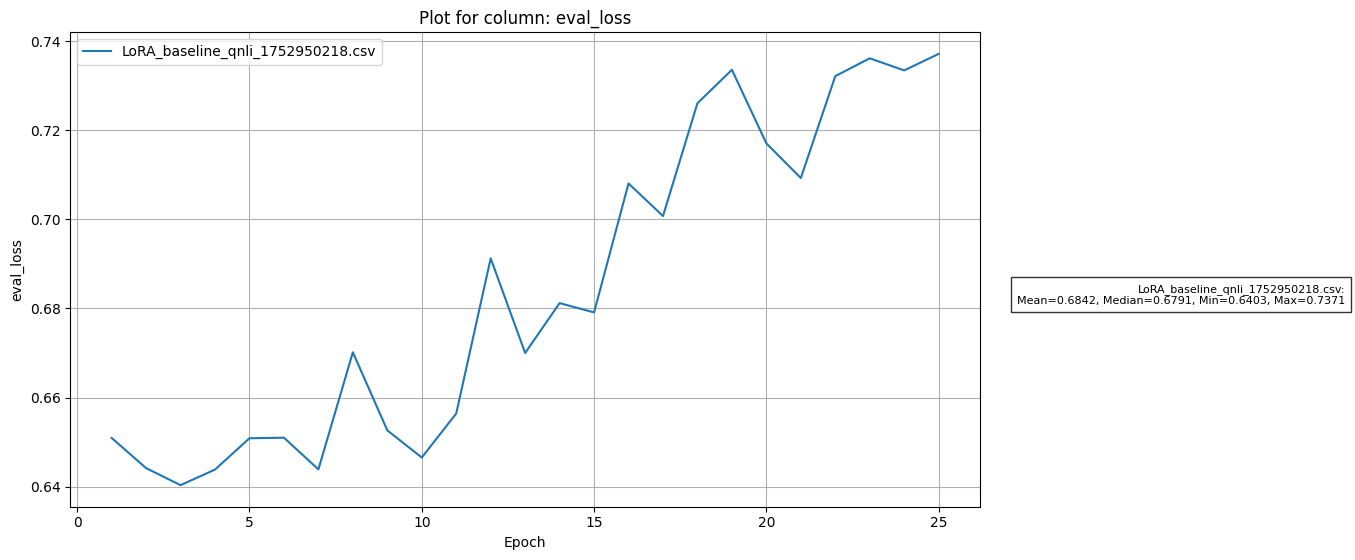

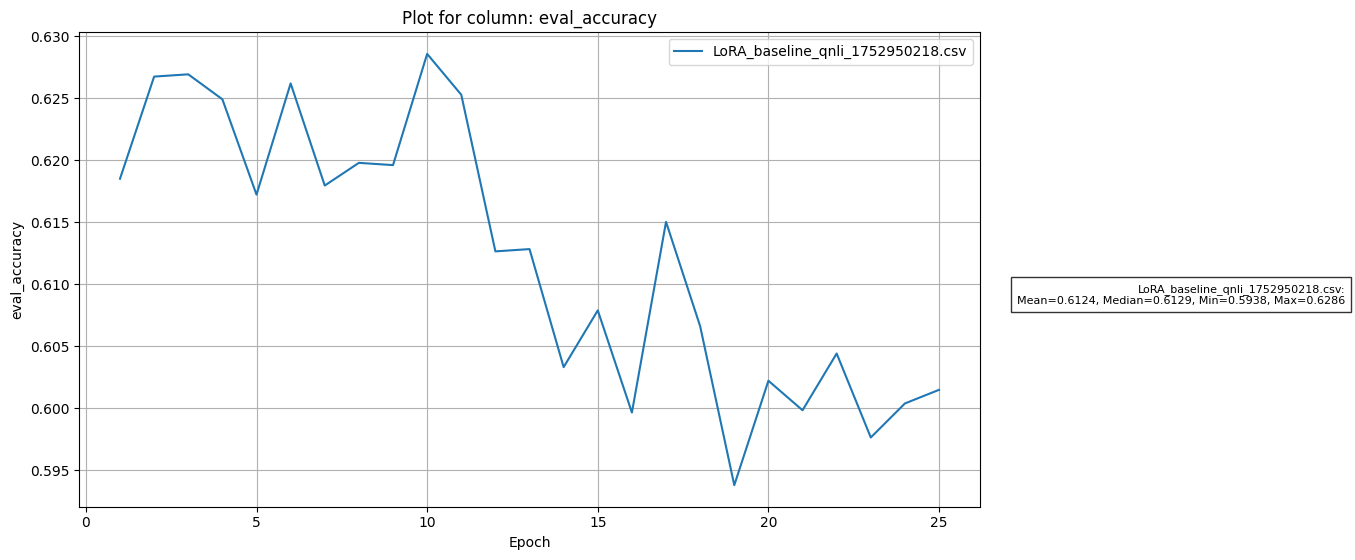

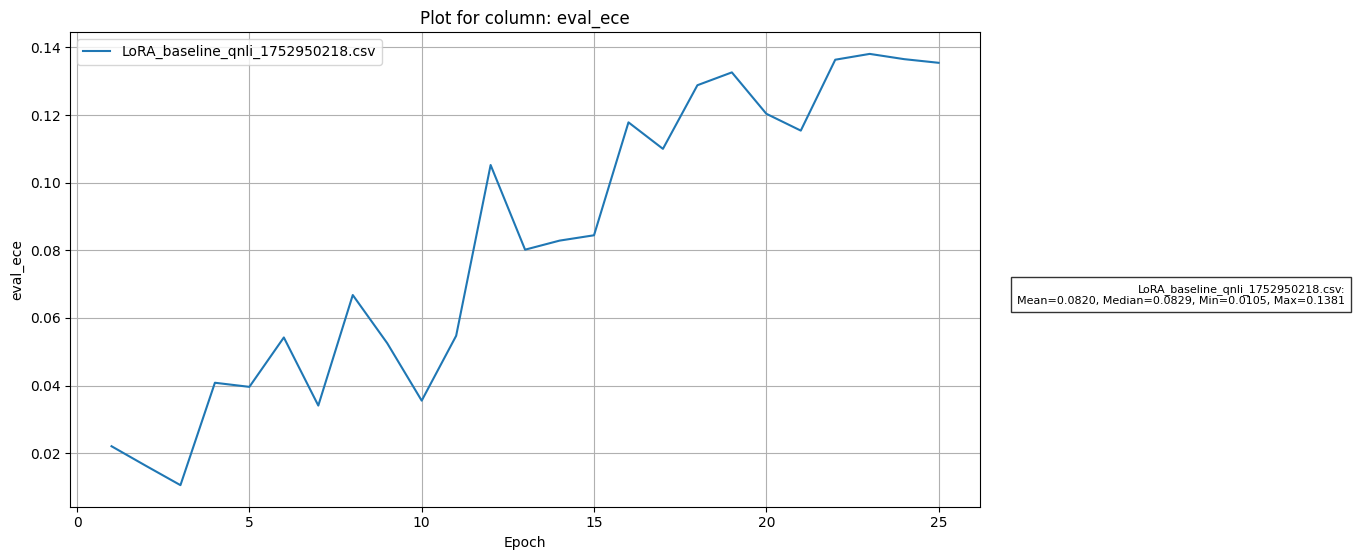

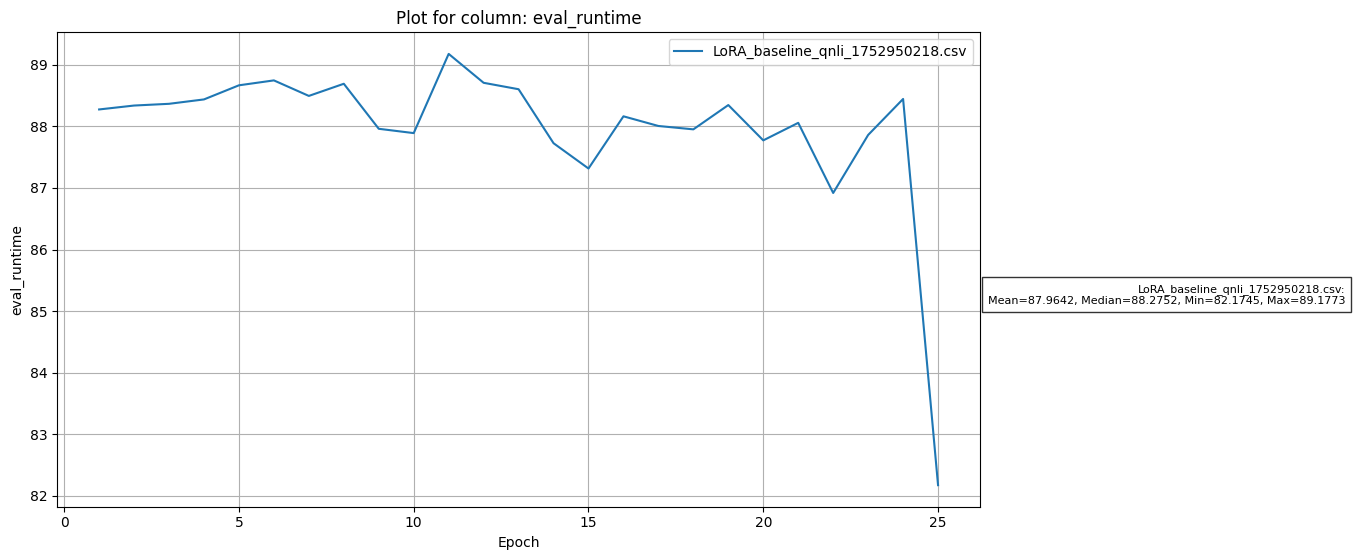

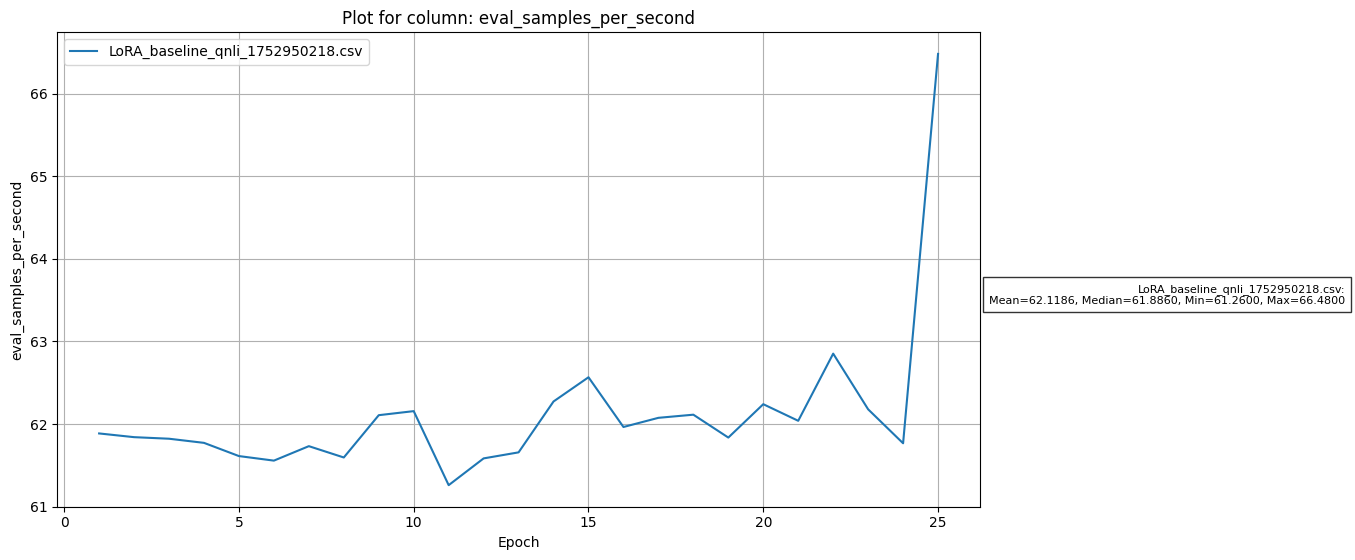

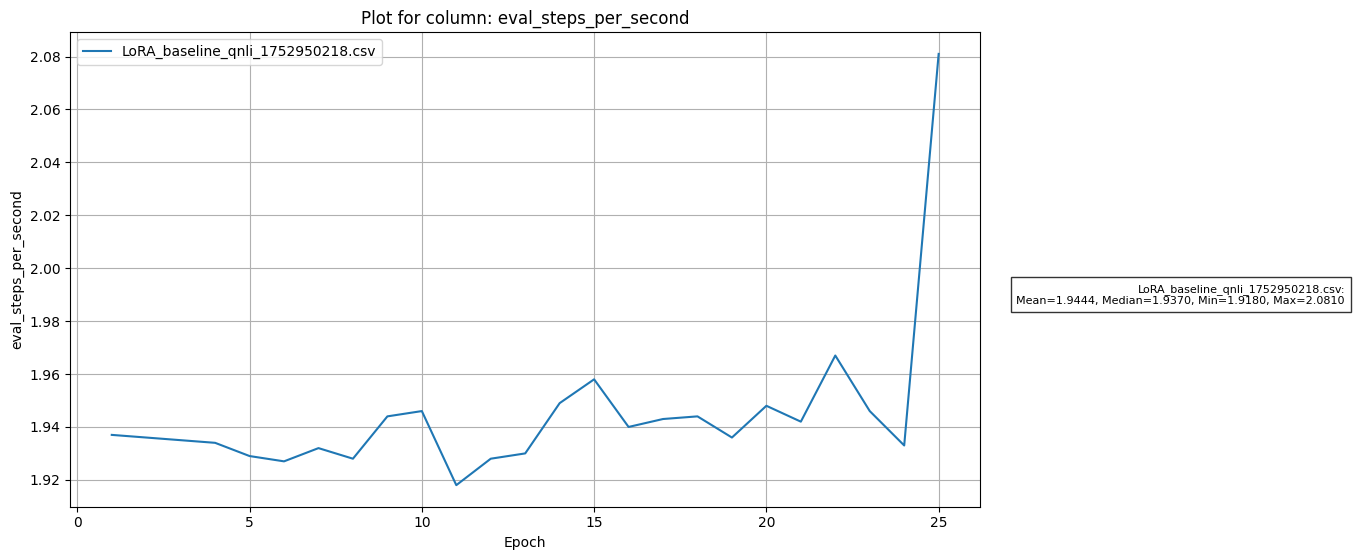

In [12]:
dir_name = "./results/lora_baselines/qnli/"
csv_files = [dir_name + file for file in os.listdir(dir_name)]

plot_csv_columns(csv_files[:1])